<a href="https://colab.research.google.com/github/PulkitTiwari87/Music-Genre-CNN/blob/main/Music_Genre_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!pip install -q kagglehub

In [7]:
import kagglehub

path = kagglehub.dataset_download(
    "andradaolteanu/gtzan-dataset-music-genre-classification"
)

print("Dataset path:", path)

Using Colab cache for faster access to the 'gtzan-dataset-music-genre-classification' dataset.
Dataset path: /kaggle/input/gtzan-dataset-music-genre-classification


In [8]:
import os

print(os.listdir(path))

['Data']


In [9]:
for root, dirs, files in os.walk(path):
    print(root)
    print("Folders:", dirs[:10])
    print("Files:", files[:5])
    print()

/kaggle/input/gtzan-dataset-music-genre-classification
Folders: ['Data']
Files: []

/kaggle/input/gtzan-dataset-music-genre-classification/Data
Folders: ['images_original', 'genres_original']
Files: ['features_3_sec.csv', 'features_30_sec.csv']

/kaggle/input/gtzan-dataset-music-genre-classification/Data/images_original
Folders: ['disco', 'metal', 'reggae', 'blues', 'rock', 'classical', 'jazz', 'hiphop', 'country', 'pop']
Files: []

/kaggle/input/gtzan-dataset-music-genre-classification/Data/images_original/disco
Folders: []
Files: ['disco00005.png', 'disco00057.png', 'disco00020.png', 'disco00072.png', 'disco00040.png']

/kaggle/input/gtzan-dataset-music-genre-classification/Data/images_original/metal
Folders: []
Files: ['metal00022.png', 'metal00042.png', 'metal00033.png', 'metal00064.png', 'metal00039.png']

/kaggle/input/gtzan-dataset-music-genre-classification/Data/images_original/reggae
Folders: []
Files: ['reggae00022.png', 'reggae00045.png', 'reggae00061.png', 'reggae00034.png'

In [10]:
import os

for root, dirs, files in os.walk(path):
    wav_files = [f for f in files if f.endswith(".wav")]

    if wav_files:
        print("Audio directory:")
        print(root)
        print("Number of wav files:", len(wav_files))

Audio directory:
/kaggle/input/gtzan-dataset-music-genre-classification/Data/genres_original/disco
Number of wav files: 100
Audio directory:
/kaggle/input/gtzan-dataset-music-genre-classification/Data/genres_original/metal
Number of wav files: 100
Audio directory:
/kaggle/input/gtzan-dataset-music-genre-classification/Data/genres_original/reggae
Number of wav files: 100
Audio directory:
/kaggle/input/gtzan-dataset-music-genre-classification/Data/genres_original/blues
Number of wav files: 100
Audio directory:
/kaggle/input/gtzan-dataset-music-genre-classification/Data/genres_original/rock
Number of wav files: 100
Audio directory:
/kaggle/input/gtzan-dataset-music-genre-classification/Data/genres_original/classical
Number of wav files: 100
Audio directory:
/kaggle/input/gtzan-dataset-music-genre-classification/Data/genres_original/jazz
Number of wav files: 100
Audio directory:
/kaggle/input/gtzan-dataset-music-genre-classification/Data/genres_original/hiphop
Number of wav files: 100
Audi

In [11]:
DATASET_PATH = "/kaggle/input/gtzan-dataset-music-genre-classification/Data/genres_original"

print(DATASET_PATH)

/kaggle/input/gtzan-dataset-music-genre-classification/Data/genres_original


In [12]:
import os

genres = sorted(os.listdir(DATASET_PATH))

print("Genres:")
for genre in genres:
    print(genre)

print("\nNumber of genres:", len(genres))

Genres:
blues
classical
country
disco
hiphop
jazz
metal
pop
reggae
rock

Number of genres: 10


In [13]:
import librosa

file_path = os.path.join(
    DATASET_PATH,
    "rock",
    "rock.00000.wav"
)

audio, sr = librosa.load(
    file_path,
    sr=22050
)

print("File:", file_path)
print("Sample rate:", sr)
print("Number of samples:", len(audio))
print("Duration:", len(audio) / sr, "seconds")

File: /kaggle/input/gtzan-dataset-music-genre-classification/Data/genres_original/rock/rock.00000.wav
Sample rate: 22050
Number of samples: 661794
Duration: 30.013333333333332 seconds


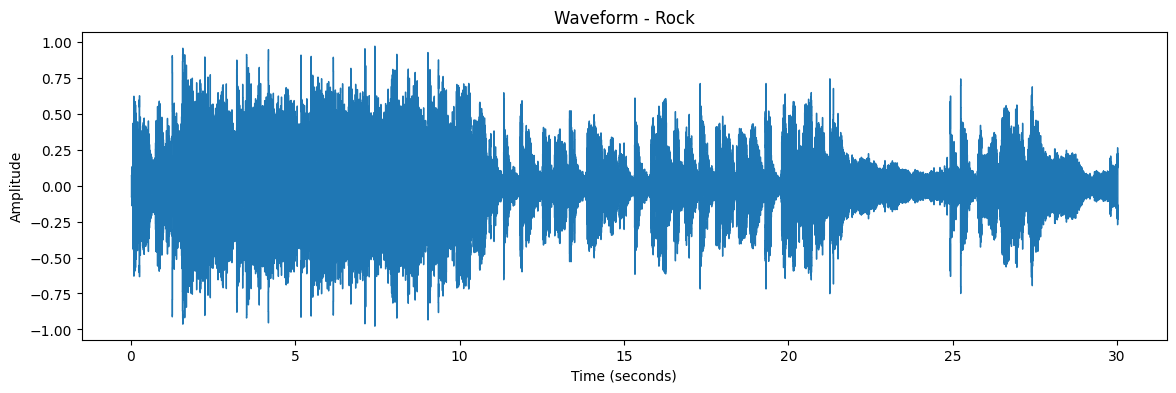

In [14]:
import matplotlib.pyplot as plt
import librosa.display

plt.figure(figsize=(14, 4))

librosa.display.waveshow(
    audio,
    sr=sr
)

plt.title("Waveform - Rock")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

In [15]:
mel_spectrogram = librosa.feature.melspectrogram(
    y=audio,
    sr=sr,
    n_mels=128
)

print("Mel spectrogram shape:", mel_spectrogram.shape)

Mel spectrogram shape: (128, 1293)


In [16]:
import numpy as np

mel_spectrogram = librosa.feature.melspectrogram(
    y=audio,
    sr=sr,
    n_mels=128
)

mel_db = librosa.power_to_db(
    mel_spectrogram,
    ref=np.max
)

print("Mel spectrogram shape:", mel_db.shape)

Mel spectrogram shape: (128, 1293)


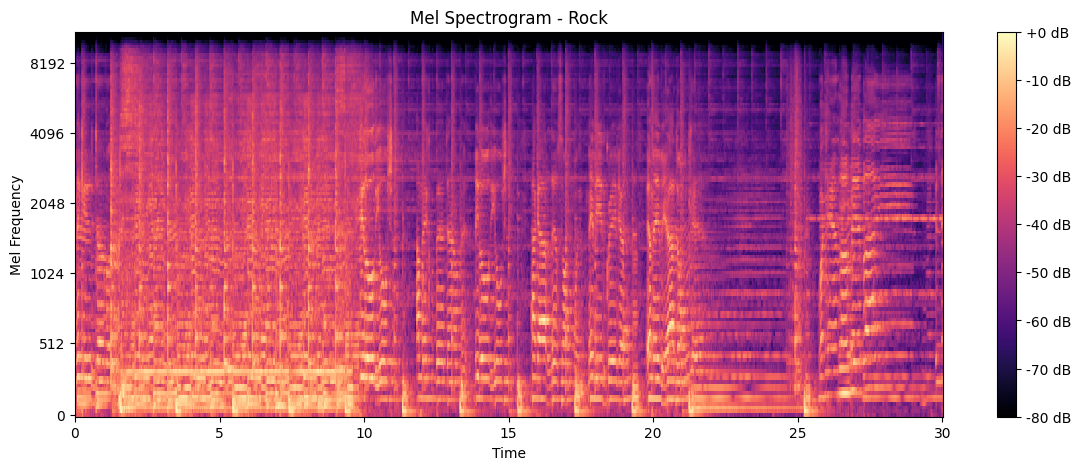

In [17]:
plt.figure(figsize=(14, 5))

librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Mel Spectrogram - Rock")
plt.xlabel("Time")
plt.ylabel("Mel Frequency")

plt.show()

In [18]:
def extract_mel_spectrogram(file_path):

    # Load audio
    audio, sr = librosa.load(
        file_path,
        sr=22050
    )

    # Generate Mel Spectrogram
    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=128
    )

    # Convert to decibels
    mel_db = librosa.power_to_db(
        mel,
        ref=np.max
    )

    return mel_db

In [19]:
feature = extract_mel_spectrogram(file_path)

print("Feature shape:", feature.shape)

Feature shape: (128, 1293)


Data preprocessing

In [20]:
import os
import pandas as pd

file_paths = []
labels = []

for genre in genres:

    genre_path = os.path.join(DATASET_PATH, genre)

    for file_name in os.listdir(genre_path):

        if file_name.endswith(".wav"):

            file_path = os.path.join(
                genre_path,
                file_name
            )

            file_paths.append(file_path)
            labels.append(genre)

df = pd.DataFrame({
    "file_path": file_paths,
    "genre": labels
})

print("Total audio files:", len(df))

df.head()

Total audio files: 1000


,file_path,genre
0,/kaggle/input/gtzan-dataset-music-genre-classi...,blues
1,/kaggle/input/gtzan-dataset-music-genre-classi...,blues
2,/kaggle/input/gtzan-dataset-music-genre-classi...,blues
3,/kaggle/input/gtzan-dataset-music-genre-classi...,blues
4,/kaggle/input/gtzan-dataset-music-genre-classi...,blues


In [21]:
print(df["genre"].value_counts())

genre
blues        100
classical    100
country      100
disco        100
hiphop       100
jazz         100
metal        100
pop          100
reggae       100
rock         100
Name: count, dtype: int64


In [22]:
from sklearn.model_selection import train_test_split

In [23]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["genre"],
    random_state=42
)

In [24]:
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["genre"],
    random_state=42
)

In [25]:
print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Testing:", len(test_df))

Training: 700
Validation: 150
Testing: 150


In [26]:
print("TRAINING")
print(train_df["genre"].value_counts())

print("\nVALIDATION")
print(val_df["genre"].value_counts())

print("\nTESTING")
print(test_df["genre"].value_counts())

TRAINING
genre
reggae       70
country      70
classical    70
hiphop       70
rock         70
disco        70
pop          70
jazz         70
metal        70
blues        70
Name: count, dtype: int64

VALIDATION
genre
jazz         15
rock         15
metal        15
hiphop       15
pop          15
country      15
blues        15
disco        15
reggae       15
classical    15
Name: count, dtype: int64

TESTING
genre
disco        15
pop          15
rock         15
metal        15
jazz         15
reggae       15
classical    15
hiphop       15
blues        15
country      15
Name: count, dtype: int64


In [27]:
import numpy as np
import librosa

SAMPLE_RATE = 22050
SEGMENT_DURATION = 3

SEGMENT_SAMPLES = SAMPLE_RATE * SEGMENT_DURATION

N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512

In [28]:
def extract_segments(file_path):

    audio, sr = librosa.load(
        file_path,
        sr=SAMPLE_RATE
    )

    segments = []

    for start in range(
        0,
        len(audio) - SEGMENT_SAMPLES + 1,
        SEGMENT_SAMPLES
    ):

        audio_segment = audio[
            start:start + SEGMENT_SAMPLES
        ]

        mel = librosa.feature.melspectrogram(
            y=audio_segment,
            sr=sr,
            n_mels=N_MELS,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH
        )

        mel_db = librosa.power_to_db(
            mel,
            ref=np.max
        )

        segments.append(mel_db)

    return segments

In [29]:
test_file = train_df.iloc[0]["file_path"]

segments = extract_segments(test_file)

print("Number of segments:", len(segments))
print("First segment shape:", segments[0].shape)

Number of segments: 10
First segment shape: (128, 130)


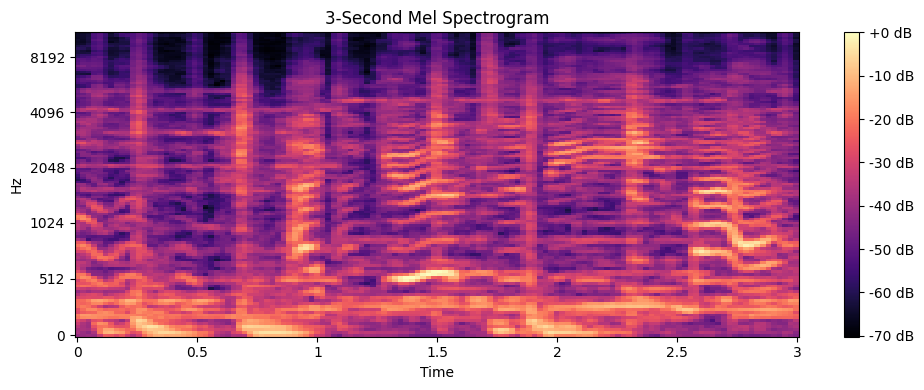

In [30]:
plt.figure(figsize=(10, 4))

librosa.display.specshow(
    segments[0],
    sr=SAMPLE_RATE,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f dB")
plt.title("3-Second Mel Spectrogram")
plt.tight_layout()
plt.show()

In [31]:
print("Total:", len(df))

Total: 1000


In [32]:
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 700
Validation: 150
Test: 150


In [33]:
segments = extract_segments(train_df.iloc[0]["file_path"])

print("Segments:", len(segments))
print("Shape:", segments[0].shape)

Segments: 10
Shape: (128, 130)


Feature Extractor

In [34]:
import numpy as np
import librosa

SAMPLE_RATE = 22050
SEGMENT_DURATION = 3

SEGMENT_SAMPLES = SAMPLE_RATE * SEGMENT_DURATION

N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512


def extract_segments(file_path):

    audio, sr = librosa.load(
        file_path,
        sr=SAMPLE_RATE
    )

    segments = []

    for start in range(
        0,
        len(audio) - SEGMENT_SAMPLES + 1,
        SEGMENT_SAMPLES
    ):

        audio_segment = audio[
            start:start + SEGMENT_SAMPLES
        ]

        # Mel Spectrogram
        mel = librosa.feature.melspectrogram(
            y=audio_segment,
            sr=sr,
            n_mels=N_MELS,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH
        )

        # Convert to decibels
        mel_db = librosa.power_to_db(
            mel,
            ref=np.max
        )

        # Limit range to -80 dB to 0 dB
        mel_db = np.clip(
            mel_db,
            -80,
            0
        )

        # Normalize to 0-1
        mel_db = (mel_db + 80) / 80

        # Convert to float32 to reduce memory
        mel_db = mel_db.astype(np.float32)

        segments.append(mel_db)

    return segments

Normalization

In [35]:
segments = extract_segments(
    train_df.iloc[0]["file_path"]
)

print("Number of segments:", len(segments))
print("Shape:", segments[0].shape)
print("Minimum:", segments[0].min())
print("Maximum:", segments[0].max())

Number of segments: 10
Shape: (128, 130)
Minimum: 0.12206583
Maximum: 1.0


In [36]:
from tqdm import tqdm


def create_dataset(dataframe):

    X = []
    y = []

    for _, row in tqdm(
        dataframe.iterrows(),
        total=len(dataframe)
    ):

        file_path = row["file_path"]
        genre = row["genre"]

        try:

            segments = extract_segments(file_path)

            for segment in segments:

                X.append(segment)
                y.append(genre)

        except Exception as e:

            print(
                f"Error processing {file_path}: {e}"
            )

    X = np.array(X, dtype=np.float32)
    y = np.array(y)

    return X, y

Process the Training Data

In [37]:
X_train, y_train = create_dataset(train_df)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

  9%|▊         | 60/700 [00:06<01:06,  9.59it/s]/tmp/ipykernel_498/1488276154.py:16: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
  9%|▉         | 62/700 [00:06<01:27,  7.33it/s]

Error processing /kaggle/input/gtzan-dataset-music-genre-classification/Data/genres_original/jazz/jazz.00054.wav: 


100%|██████████| 700/700 [01:35<00:00,  7.35it/s]


X_train shape: (6985, 128, 130)
y_train shape: (6985,)


Process validation data

In [38]:
X_val, y_val = create_dataset(val_df)

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

100%|██████████| 150/150 [00:27<00:00,  5.45it/s]

X_val shape: (1497, 128, 130)
y_val shape: (1497,)


Process test data

In [39]:
X_test, y_test = create_dataset(test_df)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

100%|██████████| 150/150 [00:17<00:00,  8.56it/s]

X_test shape: (1499, 128, 130)
y_test shape: (1499,)


Add the CNN channel dimension

In [40]:
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

In [41]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (6985, 128, 130, 1)
X_val: (1497, 128, 130, 1)
X_test: (1499, 128, 130, 1)


Convert genre names into numbers

In [42]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)

y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

In [43]:
print(label_encoder.classes_)

['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']


Convert labels to one-hot encoding

In [44]:
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(
    y_train_encoded,
    num_classes=10
)

y_val_cat = to_categorical(
    y_val_encoded,
    num_classes=10
)

y_test_cat = to_categorical(
    y_test_encoded,
    num_classes=10
)

In [45]:
print("========== DATASET ==========")

print("X_train:", X_train.shape)
print("y_train:", y_train_cat.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val_cat.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test_cat.shape)

print("\n========== LABELS ==========")

for i, genre in enumerate(label_encoder.classes_):
    print(i, "→", genre)

========== DATASET ==========
X_train: (6985, 128, 130, 1)
y_train: (6985, 10)
X_val: (1497, 128, 130, 1)
y_val: (1497, 10)
X_test: (1499, 128, 130, 1)
y_test: (1499, 10)

========== LABELS ==========
0 → blues
1 → classical
2 → country
3 → disco
4 → hiphop
5 → jazz
6 → metal
7 → pop
8 → reggae
9 → rock


Save the processed dataset

In [46]:
np.savez_compressed(
    "/content/music_genre_features.npz",
    X_train=X_train,
    y_train=y_train_cat,
    X_val=X_val,
    y_val=y_val_cat,
    X_test=X_test,
    y_test=y_test_cat
)

print("Dataset saved successfully!")

Dataset saved successfully!


In [47]:
import json

with open("/content/genre_labels.json", "w") as f:
    json.dump(
        label_encoder.classes_.tolist(),
        f
    )

print("Labels saved successfully!")

Labels saved successfully!


Verify the files

In [48]:
import os

print(os.listdir("/content"))

['.config', 'genre_labels.json', 'music_genre_features.npz', 'sample_data']


Verify your dataset shapes

In [49]:
print("X_train:", X_train.shape)
print("y_train:", y_train_cat.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val_cat.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test_cat.shape)

X_train: (6985, 128, 130, 1)
y_train: (6985, 10)
X_val: (1497, 128, 130, 1)
y_val: (1497, 10)
X_test: (1499, 128, 130, 1)
y_test: (1499, 10)


Now we're ready for the CNN

In [50]:
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Flatten,
    Dense
)

create the model:

In [51]:
model = Sequential([

    # Input
    Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(128, 130, 1)
    ),

    BatchNormalization(),

    MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Second convolution block
    Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    BatchNormalization(),

    MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Third convolution block
    Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),

    BatchNormalization(),

    MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Classification
    Flatten(),

    Dense(
        256,
        activation="relu"
    ),

    Dropout(0.5),

    Dense(
        10,
        activation="softmax"
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


What did we just create?

Our architecture is:
Input
128 × 130 × 1
       │
       ▼
Conv2D 32 filters
       │
       ▼
BatchNorm
       │
       ▼
MaxPooling
       │
       ▼
Conv2D 64 filters
       │
       ▼
BatchNorm
       │
       ▼
MaxPooling
       │
       ▼
Conv2D 128 filters
       │
       ▼
BatchNorm
       │
       ▼
MaxPooling
       │
       ▼
Flatten
       │
       ▼
Dense 256
       │
       ▼
Dropout 50%
       │
       ▼
Dense 10
       │
       ▼
Softmax
       │
       ▼
10 Genres

In [52]:
Dense(10, activation="softmax")

<Dense name=dense_2, built=False>

In [53]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 62, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 62, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 29, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 29, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,518,922 (24.87 MB)

 Trainable params: 6,518,474 (24.87 MB)

 Non-trainable params: 448 (1.75 KB)

Compile the CNN

In [54]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [55]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [56]:
import numpy as np

data = np.load(
    "/content/music_genre_features.npz"
)

X_train = data["X_train"]
y_train_cat = data["y_train"]

X_val = data["X_val"]
y_val_cat = data["y_val"]

X_test = data["X_test"]
y_test_cat = data["y_test"]

print("X_train:", X_train.shape)
print("y_train:", y_train_cat.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val_cat.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test_cat.shape)

X_train: (6985, 128, 130, 1)
y_train: (6985, 10)
X_val: (1497, 128, 130, 1)
y_val: (1497, 10)
X_test: (1499, 128, 130, 1)
y_test: (1499, 10)


In [57]:
print("X_train:", X_train.shape)
print("y_train:", y_train_cat.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val_cat.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test_cat.shape)

print(tf.config.list_physical_devices("GPU"))

model.summary()

X_train: (6985, 128, 130, 1)
y_train: (6985, 10)
X_val: (1497, 128, 130, 1)
y_val: (1497, 10)
X_test: (1499, 128, 130, 1)
y_test: (1499, 10)
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 62, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 62, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 29, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 29, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,518,922 (24.87 MB)

 Trainable params: 6,518,474 (24.87 MB)

 Non-trainable params: 448 (1.75 KB)

Model Training

In [58]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [59]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 62, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 62, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 29, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 29, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,518,922 (24.87 MB)

 Trainable params: 6,518,474 (24.87 MB)

 Non-trainable params: 448 (1.75 KB)

Mount Google Drive

In [60]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [61]:
import os

MODEL_DIR = "/content/drive/MyDrive/MusicGenreCNN/models"

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

print(MODEL_DIR)

/content/drive/MyDrive/MusicGenreCNN/models


In [62]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

In [63]:
checkpoint = ModelCheckpoint(
    filepath=f"{MODEL_DIR}/best_music_genre_cnn.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

In [64]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [65]:
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

Training

In [66]:
history = model.fit(
    X_train,
    y_train_cat,

    validation_data=(
        X_val,
        y_val_cat
    ),

    epochs=30,

    batch_size=32,

    callbacks=[
        checkpoint,
        early_stopping,
        reduce_lr
    ],

    verbose=1
)

Epoch 1/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.2142 - loss: 4.7715
Epoch 1: val_accuracy improved from None to 0.10621, saving model to /content/drive/MyDrive/MusicGenreCNN/models/best_music_genre_cnn.keras

Epoch 1: finished saving model to /content/drive/MyDrive/MusicGenreCNN/models/best_music_genre_cnn.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 21s 56ms/step - accuracy: 0.2517 - loss: 2.7311 - val_accuracy: 0.1062 - val_loss: 15.9011 - learning_rate: 0.0010
Epoch 2/30
217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2990 - loss: 1.9114
Epoch 2: val_accuracy improved from 0.10621 to 0.12692, saving model to /content/drive/MyDrive/MusicGenreCNN/models/best_music_genre_cnn.keras

Epoch 2: finished saving model to /content/drive/MyDrive/MusicGenreCNN/models/best_music_genre_cnn.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.3074 - loss: 1.8985 - val_accuracy: 0.1269 - val_loss: 9.8111 - learning_rate: 0.0010
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 21

In [67]:
print("Training complete!")

Training complete!


In [68]:
best_model = tf.keras.models.load_model(
    f"{MODEL_DIR}/best_music_genre_cnn.keras"
)

print("Best model loaded successfully!")

Best model loaded successfully!


In [69]:
test_loss, test_accuracy = best_model.evaluate(
    X_test,
    y_test_cat,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.7338 - loss: 0.9649
Test Loss: 0.9649317264556885
Test Accuracy: 0.7338225245475769


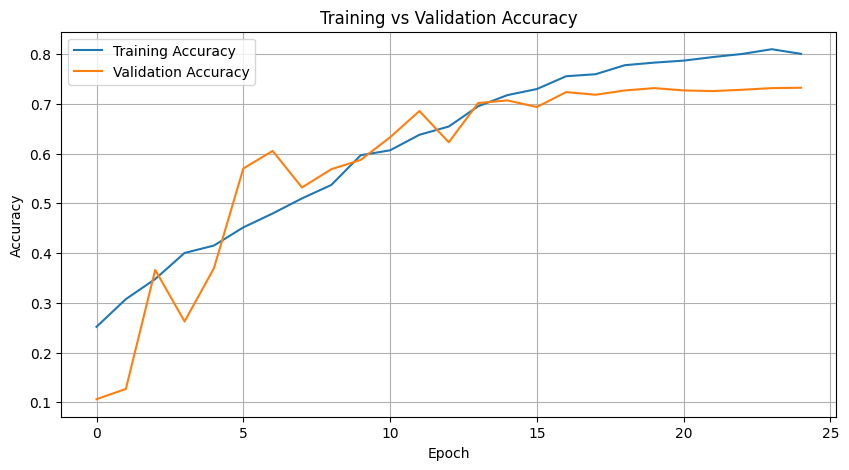

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

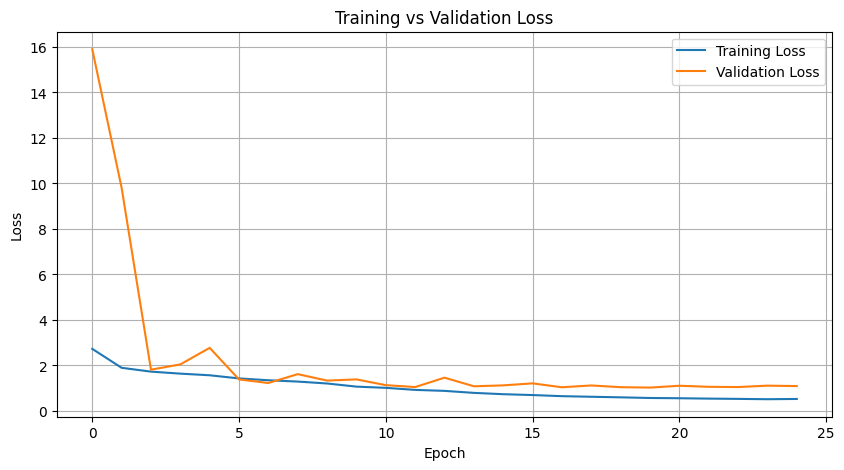

In [71]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

Generate predictions

In [72]:
import numpy as np

y_pred_prob = best_model.predict(
    X_test,
    batch_size=32,
    verbose=1
)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

y_true = np.argmax(
    y_test_cat,
    axis=1
)

print("Predictions generated.")

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
Predictions generated.


Classification report

In [73]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=label_encoder.classes_,
        digits=4
    )
)

              precision    recall  f1-score   support

       blues     0.7425    0.8267    0.7823       150
   classical     0.8684    0.8800    0.8742       150
     country     0.6786    0.6333    0.6552       150
       disco     0.7260    0.7067    0.7162       150
      hiphop     0.6879    0.7987    0.7391       149
        jazz     0.6529    0.7400    0.6937       150
       metal     0.8553    0.8667    0.8609       150
         pop     0.7192    0.7000    0.7095       150
      reggae     0.8359    0.7133    0.7698       150
        rock     0.5680    0.4733    0.5164       150

    accuracy                         0.7338      1499
   macro avg     0.7335    0.7339    0.7317      1499
weighted avg     0.7335    0.7338    0.7317      1499



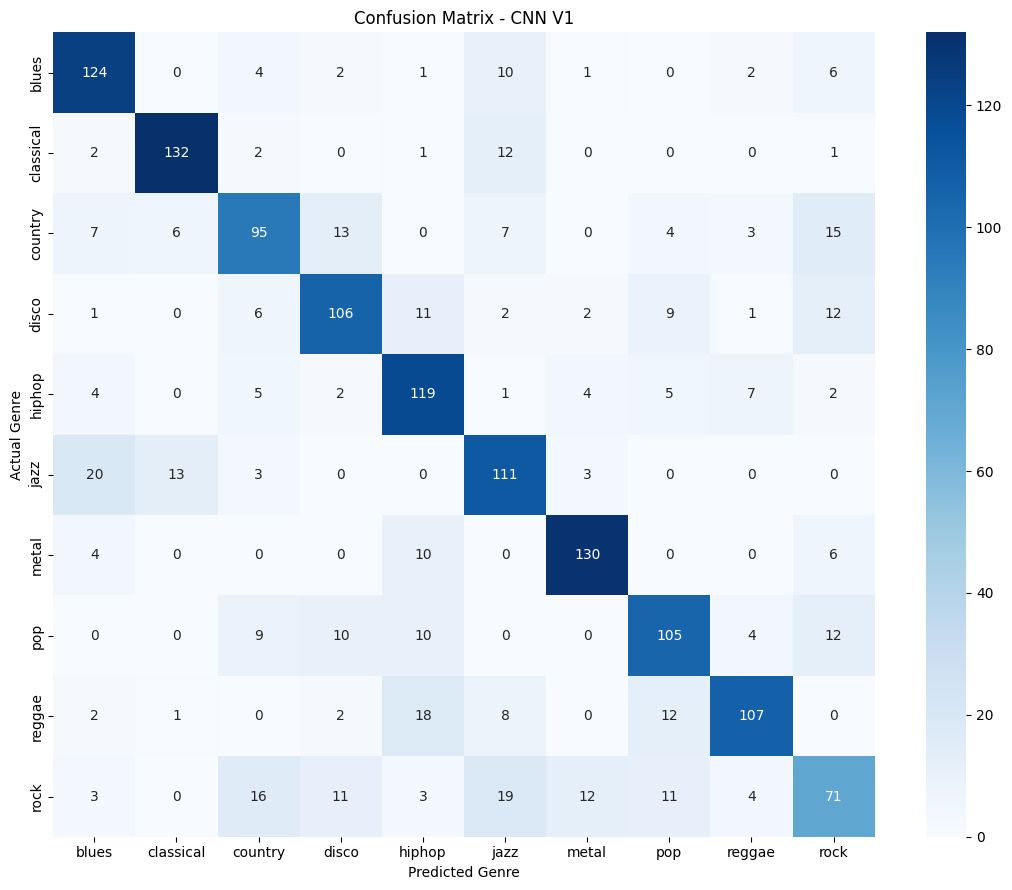

In [74]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(11, 9))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")
plt.title("Confusion Matrix - CNN V1")

plt.tight_layout()
plt.show()

In [75]:
import pandas as pd
import numpy as np

confusion_pairs = []

for actual in range(len(label_encoder.classes_)):

    for predicted in range(len(label_encoder.classes_)):

        if actual != predicted:

            confusion_pairs.append({
                "Actual": label_encoder.classes_[actual],
                "Predicted": label_encoder.classes_[predicted],
                "Count": cm[actual][predicted]
            })

confusion_pairs_df = pd.DataFrame(confusion_pairs)

confusion_pairs_df = confusion_pairs_df.sort_values(
    "Count",
    ascending=False
)

confusion_pairs_df.head(15)

,Actual,Predicted,Count
45,jazz,blues,20
86,rock,jazz,19
76,reggae,hiphop,18
83,rock,country,16
26,country,rock,15
46,jazz,classical,13
20,country,disco,13
71,pop,rock,12
35,disco,rock,12
13,classical,jazz,12


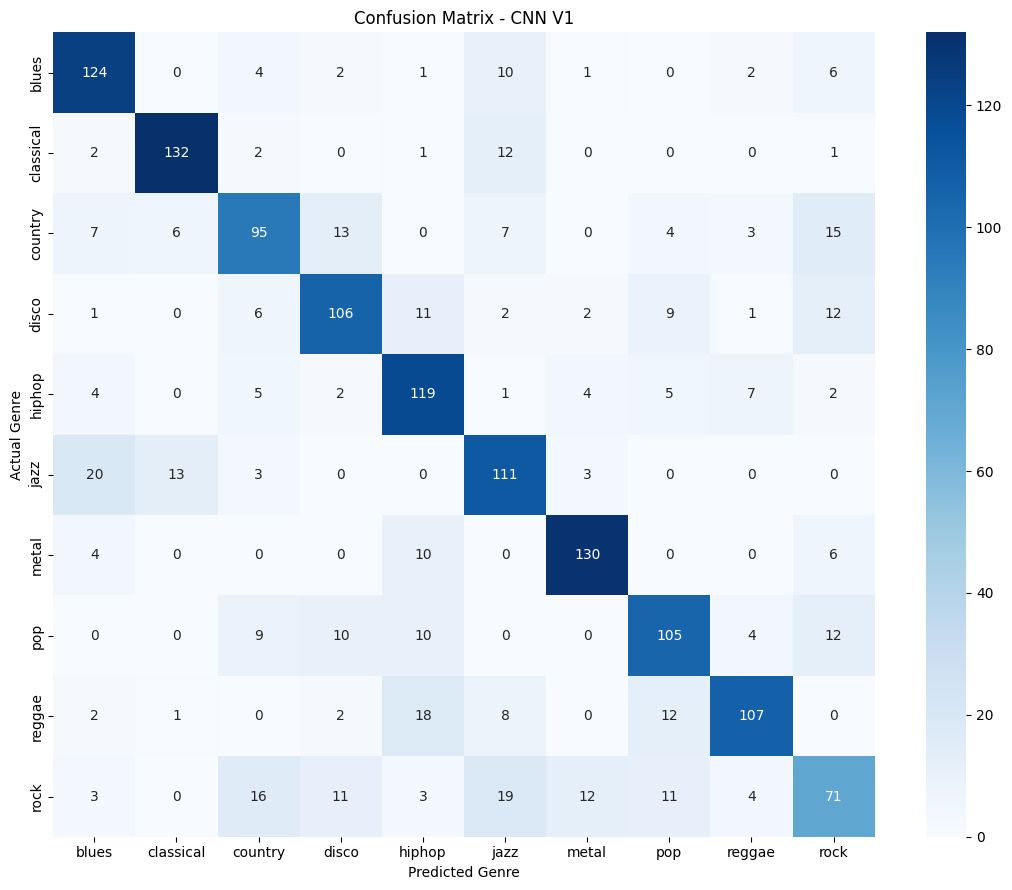

In [76]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(11, 9))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")
plt.title("Confusion Matrix - CNN V1")

plt.tight_layout()
plt.show()

Build CNN **V2**

In [77]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    BatchNormalization,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)
from tensorflow.keras.regularizers import l2

In [78]:
model_v2 = Sequential([

    Input(shape=(128, 130, 1)),

    # Block 1
    Conv2D(
        32,
        (3, 3),
        padding="same",
        activation="relu",
        kernel_regularizer=l2(1e-4)
    ),

    BatchNormalization(),

    MaxPooling2D(
        (2, 2)
    ),

    # Block 2
    Conv2D(
        64,
        (3, 3),
        padding="same",
        activation="relu",
        kernel_regularizer=l2(1e-4)
    ),

    BatchNormalization(),

    MaxPooling2D(
        (2, 2)
    ),

    # Block 3
    Conv2D(
        128,
        (3, 3),
        padding="same",
        activation="relu",
        kernel_regularizer=l2(1e-4)
    ),

    BatchNormalization(),

    MaxPooling2D(
        (2, 2)
    ),

    # Replace Flatten with Global Average Pooling
    GlobalAveragePooling2D(),

    Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(1e-4)
    ),

    Dropout(0.4),

    # 10 genres
    Dense(
        10,
        activation="softmax"
    )
])

In [79]:
model_v2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 130, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 130, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 65, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 65, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,370 (435.04 KB)

 Trainable params: 110,922 (433.29 KB)

 Non-trainable params: 448 (1.75 KB)

In [80]:
model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [81]:
MODEL_DIR = "/content/drive/MyDrive/MusicGenreCNN/models"

In [82]:
checkpoint_v2 = ModelCheckpoint(
    filepath=f"{MODEL_DIR}/best_music_genre_cnn_v2.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

In [83]:
early_stopping_v2 = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [84]:
reduce_lr_v2 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [85]:
history_v2 = model_v2.fit(
    X_train,
    y_train_cat,

    validation_data=(
        X_val,
        y_val_cat
    ),

    epochs=30,

    batch_size=32,

    callbacks=[
        checkpoint_v2,
        early_stopping_v2,
        reduce_lr_v2
    ],

    verbose=1
)

Epoch 1/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.3804 - loss: 1.7698
Epoch 1: val_accuracy improved from None to 0.10688, saving model to /content/drive/MyDrive/MusicGenreCNN/models/best_music_genre_cnn_v2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/MusicGenreCNN/models/best_music_genre_cnn_v2.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 24s 71ms/step - accuracy: 0.4703 - loss: 1.5094 - val_accuracy: 0.1069 - val_loss: 5.1356 - learning_rate: 0.0010
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5972 - loss: 1.1564
Epoch 2: val_accuracy improved from 0.10688 to 0.18303, saving model to /content/drive/MyDrive/MusicGenreCNN/models/best_music_genre_cnn_v2.keras

Epoch 2: finished saving model to /content/drive/MyDrive/MusicGenreCNN/models/best_music_genre_cnn_v2.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.6301 - loss: 1.0782 - val_accuracy: 0.1830 - val_loss: 7.2340 - learning_rate: 0.0010
Epoch 3/30
217/219 ━━━━━━━━━━━━━━━

In [86]:
best_model_v2 = tf.keras.models.load_model(
    f"{MODEL_DIR}/best_music_genre_cnn_v2.keras"
)

In [87]:
test_loss_v2, test_accuracy_v2 = best_model_v2.evaluate(
    X_test,
    y_test_cat,
    verbose=1
)

print("V2 Test Loss:", test_loss_v2)
print("V2 Test Accuracy:", test_accuracy_v2)

47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.8185 - loss: 0.7200
V2 Test Loss: 0.7200245261192322
V2 Test Accuracy: 0.8185456991195679


In [88]:
print("CNN V1 Test Accuracy:", test_accuracy)
print("CNN V2 Test Accuracy:", test_accuracy_v2)

CNN V1 Test Accuracy: 0.7338225245475769
CNN V2 Test Accuracy: 0.8185456991195679


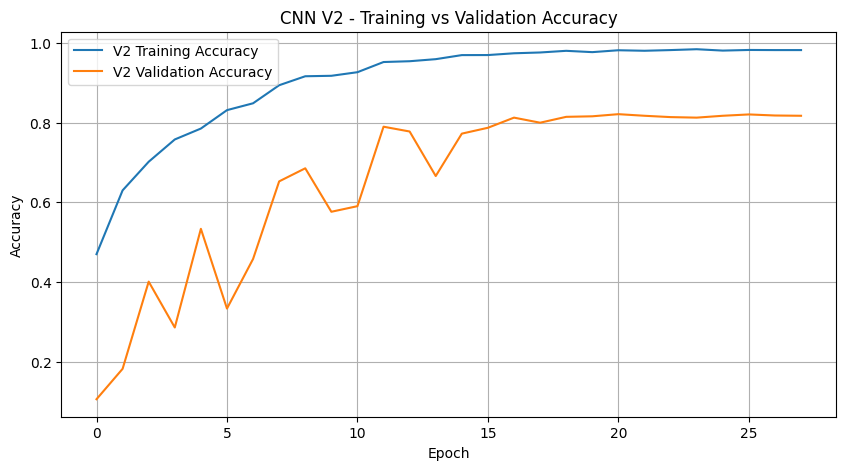

In [89]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_v2.history["accuracy"],
    label="V2 Training Accuracy"
)

plt.plot(
    history_v2.history["val_accuracy"],
    label="V2 Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN V2 - Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

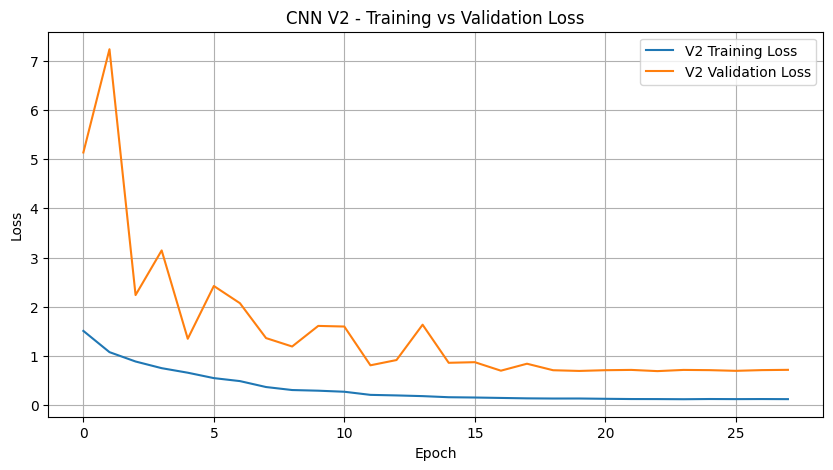

In [90]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_v2.history["loss"],
    label="V2 Training Loss"
)

plt.plot(
    history_v2.history["val_loss"],
    label="V2 Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN V2 - Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [91]:
y_pred_prob_v2 = best_model_v2.predict(
    X_test,
    batch_size=32,
    verbose=1
)

y_pred_v2 = np.argmax(
    y_pred_prob_v2,
    axis=1
)

y_true_v2 = np.argmax(
    y_test_cat,
    axis=1
)

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


In [92]:
cm_v2 = confusion_matrix(
    y_true_v2,
    y_pred_v2
)

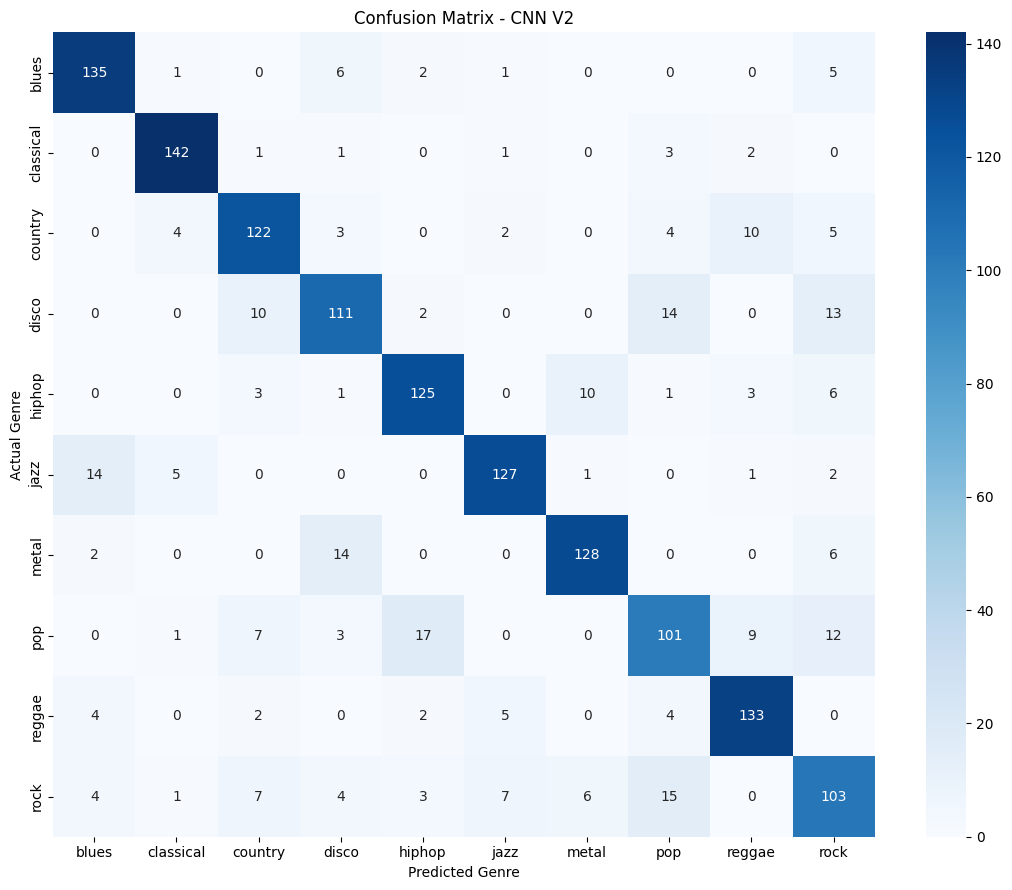

In [93]:
plt.figure(figsize=(11, 9))

sns.heatmap(
    cm_v2,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")
plt.title("Confusion Matrix - CNN V2")

plt.tight_layout()
plt.show()

In [94]:
print(
    classification_report(
        y_true_v2,
        y_pred_v2,
        target_names=label_encoder.classes_,
        digits=4
    )
)

              precision    recall  f1-score   support

       blues     0.8491    0.9000    0.8738       150
   classical     0.9221    0.9467    0.9342       150
     country     0.8026    0.8133    0.8079       150
       disco     0.7762    0.7400    0.7577       150
      hiphop     0.8278    0.8389    0.8333       149
        jazz     0.8881    0.8467    0.8669       150
       metal     0.8828    0.8533    0.8678       150
         pop     0.7113    0.6733    0.6918       150
      reggae     0.8418    0.8867    0.8636       150
        rock     0.6776    0.6867    0.6821       150

    accuracy                         0.8185      1499
   macro avg     0.8179    0.8186    0.8179      1499
weighted avg     0.8179    0.8185    0.8179      1499



**We need to preserve the original song ID**

In [95]:
def extract_segments_with_label(file_path, genre):

    audio, sr = librosa.load(
        file_path,
        sr=SAMPLE_RATE
    )

    segments = []

    for start in range(
        0,
        len(audio) - SEGMENT_SAMPLES + 1,
        SEGMENT_SAMPLES
    ):

        audio_segment = audio[
            start:start + SEGMENT_SAMPLES
        ]

        mel = librosa.feature.melspectrogram(
            y=audio_segment,
            sr=sr,
            n_mels=N_MELS,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH
        )

        mel_db = librosa.power_to_db(
            mel,
            ref=np.max
        )

        mel_db = np.clip(
            mel_db,
            -80,
            0
        )

        mel_db = (mel_db + 80) / 80

        segments.append(
            mel_db.astype(np.float32)
        )

    return np.array(segments)

**Create song-level evaluation**

In [96]:
song_results = []

for _, row in tqdm(
    test_df.iterrows(),
    total=len(test_df)
):

    file_path = row["file_path"]
    true_genre = row["genre"]

    segments = extract_segments_with_label(
        file_path,
        true_genre
    )

    segments = segments[..., np.newaxis]

    predictions = best_model_v2.predict(
        segments,
        verbose=0
    )

    # Average probabilities across all segments
    average_prediction = np.mean(
        predictions,
        axis=0
    )

    predicted_index = np.argmax(
        average_prediction
    )

    predicted_genre = label_encoder.classes_[
        predicted_index
    ]

    song_results.append({
        "file": os.path.basename(file_path),
        "actual": true_genre,
        "predicted": predicted_genre
    })

100%|██████████| 150/150 [00:42<00:00,  3.50it/s]


In [97]:
song_results_df = pd.DataFrame(
    song_results
)

song_results_df.head()

,file,actual,predicted
0,disco.00082.wav,disco,disco
1,pop.00050.wav,pop,pop
2,rock.00061.wav,rock,pop
3,metal.00073.wav,metal,metal
4,jazz.00094.wav,jazz,jazz


In [98]:
from sklearn.metrics import accuracy_score

song_accuracy = accuracy_score(
    song_results_df["actual"],
    song_results_df["predicted"]
)

print(
    f"Song-Level Accuracy: {song_accuracy * 100:.2f}%"
)

Song-Level Accuracy: 86.67%


In [99]:
song_cm = confusion_matrix(
    song_results_df["actual"],
    song_results_df["predicted"],
    labels=label_encoder.classes_
)

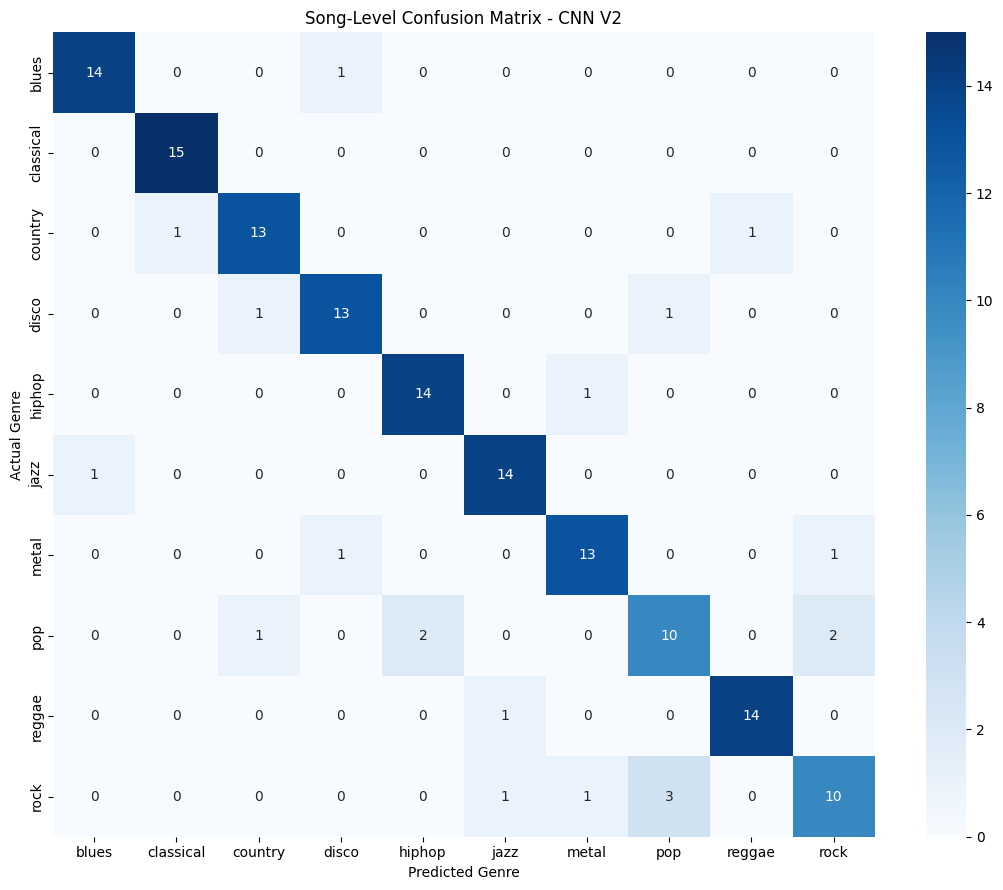

In [100]:
plt.figure(figsize=(11, 9))

sns.heatmap(
    song_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")
plt.title("Song-Level Confusion Matrix - CNN V2")

plt.tight_layout()
plt.show()

In [101]:
print(
    classification_report(
        song_results_df["actual"],
        song_results_df["predicted"],
        labels=label_encoder.classes_,
        digits=4
    )
)

              precision    recall  f1-score   support

       blues     0.9333    0.9333    0.9333        15
   classical     0.9375    1.0000    0.9677        15
     country     0.8667    0.8667    0.8667        15
       disco     0.8667    0.8667    0.8667        15
      hiphop     0.8750    0.9333    0.9032        15
        jazz     0.8750    0.9333    0.9032        15
       metal     0.8667    0.8667    0.8667        15
         pop     0.7143    0.6667    0.6897        15
      reggae     0.9333    0.9333    0.9333        15
        rock     0.7692    0.6667    0.7143        15

    accuracy                         0.8667       150
   macro avg     0.8638    0.8667    0.8645       150
weighted avg     0.8638    0.8667    0.8645       150



**CNN V3 with SpecAugment**

In [102]:
import tensorflow as tf
from tensorflow.keras import layers

In [103]:
freq_mask = layers.RandomHeight(
    factor=0.15
)

time_mask = layers.RandomWidth(
    factor=0.15
)

**Create SpecAugment**

In [104]:
class SpecAugment(layers.Layer):

    def __init__(
        self,
        freq_mask_param=12,
        time_mask_param=15,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.freq_mask_param = freq_mask_param
        self.time_mask_param = time_mask_param

    def call(self, inputs, training=None):

        if not training:
            return inputs

        x = inputs

        # Random frequency masking
        freq_mask = tf.random.uniform(
            [],
            minval=0,
            maxval=self.freq_mask_param + 1,
            dtype=tf.int32
        )

        freq_start = tf.random.uniform(
            [],
            minval=0,
            maxval=tf.shape(x)[1] - freq_mask + 1,
            dtype=tf.int32
        )

        freq_mask_tensor = tf.concat([
            tf.ones(
                [freq_start, 1, 1],
                dtype=x.dtype
            ),
            tf.zeros(
                [freq_mask, 1, 1],
                dtype=x.dtype
            ),
            tf.ones(
                [
                    tf.shape(x)[1] - freq_start - freq_mask,
                    1,
                    1
                ],
                dtype=x.dtype
            )
        ], axis=0)

        x = x * freq_mask_tensor

        # Random time masking
        time_mask = tf.random.uniform(
            [],
            minval=0,
            maxval=self.time_mask_param + 1,
            dtype=tf.int32
        )

        time_start = tf.random.uniform(
            [],
            minval=0,
            maxval=tf.shape(x)[2] - time_mask + 1,
            dtype=tf.int32
        )

        time_mask_tensor = tf.concat([
            tf.ones(
                [1, time_start, 1],
                dtype=x.dtype
            ),
            tf.zeros(
                [1, time_mask, 1],
                dtype=x.dtype
            ),
            tf.ones(
                [
                    1,
                    tf.shape(x)[2] - time_start - time_mask,
                    1
                ],
                dtype=x.dtype
            )
        ], axis=1)

        x = x * time_mask_tensor

        return x

SAVING

In [105]:
import json

results = {
    "CNN_V1": {
        "segment_accuracy": 0.7338
    },
    "CNN_V2": {
        "segment_accuracy": 0.8158,
        "song_accuracy": 0.8667,
        "song_macro_f1": 0.8645
    }
}

with open(
    "/content/drive/MyDrive/MusicGenreCNN/experiment_results.json",
    "w"
) as f:

    json.dump(
        results,
        f,
        indent=4
    )

print("Experiment results saved.")

Experiment results saved.


In [106]:
V1_PATH = os.path.join(
    MODEL_DIR,
    "CNN_V1_best.keras"
)

best_model.save(V1_PATH)

print("CNN V1 saved:")
print(V1_PATH)

CNN V1 saved:
/content/drive/MyDrive/MusicGenreCNN/models/CNN_V1_best.keras


In [107]:
V2_PATH = os.path.join(
    MODEL_DIR,
    "CNN_V2_best.keras"
)

best_model_v2.save(V2_PATH)

print("CNN V2 saved:")
print(V2_PATH)

CNN V2 saved:
/content/drive/MyDrive/MusicGenreCNN/models/CNN_V2_best.keras


In [108]:
print(os.listdir(MODEL_DIR))

['best_music_genre_cnn.keras', 'best_music_genre_cnn_v2.keras', 'CNN_V1_best.keras', 'CNN_V2_best.keras']


In [109]:
for file_name in os.listdir(MODEL_DIR):

    file_path = os.path.join(
        MODEL_DIR,
        file_name
    )

    size_mb = os.path.getsize(file_path) / (1024 ** 2)

    print(
        file_name,
        f"→ {size_mb:.2f} MB"
    )

best_music_genre_cnn.keras → 74.66 MB
best_music_genre_cnn_v2.keras → 1.33 MB
CNN_V1_best.keras → 74.66 MB
CNN_V2_best.keras → 1.33 MB


In [112]:
import os

PROJECT_DIR = "/content/drive/MyDrive/MusicGenreCNN"

MODEL_DIR = os.path.join(
    PROJECT_DIR,
    "models"
)

RESULTS_DIR = os.path.join(
    PROJECT_DIR,
    "results"
)

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Project:", PROJECT_DIR)
print("Models:", MODEL_DIR)
print("Results:", RESULTS_DIR)

Project: /content/drive/MyDrive/MusicGenreCNN
Models: /content/drive/MyDrive/MusicGenreCNN/models
Results: /content/drive/MyDrive/MusicGenreCNN/results


In [113]:
import json

experiment_results = {
    "CNN_V1": {
        "segment_accuracy": 0.7338
    },

    "CNN_V2": {
        "segment_accuracy": 0.8158,
        "song_accuracy": 0.8667,
        "song_macro_f1": 0.8645
    }
}

RESULTS_PATH = os.path.join(
    RESULTS_DIR,
    "experiment_results.json"
)

with open(RESULTS_PATH, "w") as f:

    json.dump(
        experiment_results,
        f,
        indent=4
    )

print("Results saved:", RESULTS_PATH)

Results saved: /content/drive/MyDrive/MusicGenreCNN/results/experiment_results.json


Training V3

In [122]:
import tensorflow as tf
from tensorflow.keras import layers


class SpecAugment(layers.Layer):

    def __init__(
        self,
        freq_mask_param=12,
        time_mask_param=15,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.freq_mask_param = freq_mask_param
        self.time_mask_param = time_mask_param

    def call(self, inputs, training=None):

        if training is False:
            return inputs

        x = inputs

        # Shape:
        # batch, frequency, time, channels
        shape = tf.shape(x)

        batch_size = shape[0]
        freq_size = shape[1]
        time_size = shape[2]

        # -------------------------
        # Frequency masking
        # -------------------------

        freq_width = tf.random.uniform(
            [],
            minval=0,
            maxval=self.freq_mask_param + 1,
            dtype=tf.int32
        )

        freq_start = tf.random.uniform(
            [],
            minval=0,
            maxval=tf.maximum(
                1,
                freq_size - freq_width + 1
            ),
            dtype=tf.int32
        )

        freq_indices = tf.range(freq_size)

        freq_condition = tf.logical_and(
            freq_indices >= freq_start,
            freq_indices < freq_start + freq_width
        )

        freq_mask = tf.cast(
            ~freq_condition,
            x.dtype
        )

        freq_mask = tf.reshape(
            freq_mask,
            [1, freq_size, 1, 1]
        )

        x = x * freq_mask


        # -------------------------
        # Time masking
        # -------------------------

        time_width = tf.random.uniform(
            [],
            minval=0,
            maxval=self.time_mask_param + 1,
            dtype=tf.int32
        )

        time_start = tf.random.uniform(
            [],
            minval=0,
            maxval=tf.maximum(
                1,
                time_size - time_width + 1
            ),
            dtype=tf.int32
        )

        time_indices = tf.range(time_size)

        time_condition = tf.logical_and(
            time_indices >= time_start,
            time_indices < time_start + time_width
        )

        time_mask = tf.cast(
            ~time_condition,
            x.dtype
        )

        time_mask = tf.reshape(
            time_mask,
            [1, 1, time_size, 1]
        )

        x = x * time_mask

        return x

In [115]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    BatchNormalization,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)
from tensorflow.keras.regularizers import l2


model_v3 = Sequential([

    Input(
        shape=(128, 130, 1)
    ),

    # =========================
    # SpecAugment
    # =========================

    SpecAugment(
        freq_mask_param=12,
        time_mask_param=15
    ),

    # =========================
    # Block 1
    # =========================

    Conv2D(
        32,
        (3, 3),
        padding="same",
        activation="relu",
        kernel_regularizer=l2(1e-4)
    ),

    BatchNormalization(),

    MaxPooling2D(
        (2, 2)
    ),


    # =========================
    # Block 2
    # =========================

    Conv2D(
        64,
        (3, 3),
        padding="same",
        activation="relu",
        kernel_regularizer=l2(1e-4)
    ),

    BatchNormalization(),

    MaxPooling2D(
        (2, 2)
    ),


    # =========================
    # Block 3
    # =========================

    Conv2D(
        128,
        (3, 3),
        padding="same",
        activation="relu",
        kernel_regularizer=l2(1e-4)
    ),

    BatchNormalization(),

    MaxPooling2D(
        (2, 2)
    ),


    # =========================
    # Block 4
    # =========================

    Conv2D(
        256,
        (3, 3),
        padding="same",
        activation="relu",
        kernel_regularizer=l2(1e-4)
    ),

    BatchNormalization(),

    MaxPooling2D(
        (2, 2)
    ),


    # =========================
    # Classification
    # =========================

    GlobalAveragePooling2D(),

    Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(1e-4)
    ),

    Dropout(0.4),

    Dense(
        10,
        activation="softmax"
    )
])

In [116]:
model_v3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ spec_augment (SpecAugment)      │ (None, 128, 130, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 130, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128, 130, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 65, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64, 65, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,946 (1.62 MB)

 Trainable params: 422,986 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [117]:
model_v3.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="categorical_crossentropy",

    metrics=["accuracy"]
)

In [118]:
V3_PATH = os.path.join(
    MODEL_DIR,
    "CNN_V3_best.keras"
)

checkpoint_v3 = tf.keras.callbacks.ModelCheckpoint(
    V3_PATH,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

In [119]:
early_stopping_v3 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
    verbose=1
)

In [120]:
reduce_lr_v3 = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [121]:
history_v3 = model_v3.fit(

    X_train,
    y_train_cat,

    validation_data=(
        X_val,
        y_val_cat
    ),

    epochs=30,

    batch_size=32,

    callbacks=[
        checkpoint_v3,
        early_stopping_v3,
        reduce_lr_v3
    ],

    verbose=1
)

Epoch 1/30


InvalidArgumentError: Graph execution error:

Detected at node sequential_2_1/spec_augment_1/ones defined at (most recent call last):
<stack traces unavailable>
Input 0 to node `sequential_2_1/spec_augment_1/ones` with op Fill must be a compile-time constant.

XLA compilation requires that operator arguments that represent shapes or dimensions be evaluated to concrete values at compile time. This error means that a shape or dimension argument could not be evaluated at compile time, usually because the value of the argument depends on a parameter to the computation, on a variable, or on a stateful operation such as a random number generator.

Stack trace for op definition: 
File "<frozen runpy>", line 198, in _run_module_as_main
File "<frozen runpy>", line 88, in _run_code
File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance
File "/usr/loc

In [123]:
import tensorflow as tf
from tensorflow.keras import layers


class SpecAugment(layers.Layer):

    def __init__(
        self,
        freq_mask_param=12,
        time_mask_param=15,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.freq_mask_param = freq_mask_param
        self.time_mask_param = time_mask_param

    def call(self, inputs, training=None):

        if training is False:
            return inputs

        x = inputs

        # Shape:
        # batch, frequency, time, channels
        shape = tf.shape(x)

        batch_size = shape[0]
        freq_size = shape[1]
        time_size = shape[2]

        # -------------------------
        # Frequency masking
        # -------------------------

        freq_width = tf.random.uniform(
            [],
            minval=0,
            maxval=self.freq_mask_param + 1,
            dtype=tf.int32
        )

        freq_start = tf.random.uniform(
            [],
            minval=0,
            maxval=tf.maximum(
                1,
                freq_size - freq_width + 1
            ),
            dtype=tf.int32
        )

        freq_indices = tf.range(freq_size)

        freq_condition = tf.logical_and(
            freq_indices >= freq_start,
            freq_indices < freq_start + freq_width
        )

        freq_mask = tf.cast(
            ~freq_condition,
            x.dtype
        )

        freq_mask = tf.reshape(
            freq_mask,
            [1, freq_size, 1, 1]
        )

        x = x * freq_mask


        # -------------------------
        # Time masking
        # -------------------------

        time_width = tf.random.uniform(
            [],
            minval=0,
            maxval=self.time_mask_param + 1,
            dtype=tf.int32
        )

        time_start = tf.random.uniform(
            [],
            minval=0,
            maxval=tf.maximum(
                1,
                time_size - time_width + 1
            ),
            dtype=tf.int32
        )

        time_indices = tf.range(time_size)

        time_condition = tf.logical_and(
            time_indices >= time_start,
            time_indices < time_start + time_width
        )

        time_mask = tf.cast(
            ~time_condition,
            x.dtype
        )

        time_mask = tf.reshape(
            time_mask,
            [1, 1, time_size, 1]
        )

        x = x * time_mask

        return x

In [124]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    BatchNormalization,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)
from tensorflow.keras.regularizers import l2


model_v3 = Sequential([

    Input(shape=(128, 130, 1)),

    SpecAugment(
        freq_mask_param=12,
        time_mask_param=15
    ),

    # Block 1
    Conv2D(
        32,
        (3, 3),
        padding="same",
        activation="relu",
        kernel_regularizer=l2(1e-4)
    ),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Block 2
    Conv2D(
        64,
        (3, 3),
        padding="same",
        activation="relu",
        kernel_regularizer=l2(1e-4)
    ),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Block 3
    Conv2D(
        128,
        (3, 3),
        padding="same",
        activation="relu",
        kernel_regularizer=l2(1e-4)
    ),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Block 4
    Conv2D(
        256,
        (3, 3),
        padding="same",
        activation="relu",
        kernel_regularizer=l2(1e-4)
    ),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Classification
    GlobalAveragePooling2D(),

    Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(1e-4)
    ),

    Dropout(0.4),

    Dense(
        10,
        activation="softmax"
    )
])

In [125]:
model_v3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ spec_augment_1 (SpecAugment)    │ (None, 128, 130, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 128, 130, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128, 130, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 64, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 65, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64, 65, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,946 (1.62 MB)

 Trainable params: 422,986 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [126]:
sample_batch = X_train[:4]

augmented_batch = model_v3.layers[1](
    sample_batch,
    training=True
)

print("Original shape:", sample_batch.shape)
print("Augmented shape:", augmented_batch.shape)

Original shape: (4, 128, 130, 1)
Augmented shape: (4, 128, 130, 32)


In [127]:
output = model_v3(sample_batch, training=True)

print("Model output shape:", output.shape)

Model output shape: (4, 10)


In [128]:
model_v3.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [129]:
V3_PATH = "/content/drive/MyDrive/MusicGenreCNN/models/CNN_V3_best.keras"

checkpoint_v3 = tf.keras.callbacks.ModelCheckpoint(
    V3_PATH,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

early_stopping_v3 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_v3 = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [130]:
history_v3 = model_v3.fit(
    X_train,
    y_train_cat,

    validation_data=(
        X_val,
        y_val_cat
    ),

    epochs=30,

    batch_size=32,

    callbacks=[
        checkpoint_v3,
        early_stopping_v3,
        reduce_lr_v3
    ],

    verbose=1
)

Epoch 1/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.3767 - loss: 1.7639
Epoch 1: val_accuracy improved from None to 0.10020, saving model to /content/drive/MyDrive/MusicGenreCNN/models/CNN_V3_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/MusicGenreCNN/models/CNN_V3_best.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 24s 65ms/step - accuracy: 0.4607 - loss: 1.5570 - val_accuracy: 0.1002 - val_loss: 6.5159 - learning_rate: 0.0010
Epoch 2/30
217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5718 - loss: 1.2399
Epoch 2: val_accuracy improved from 0.10020 to 0.16166, saving model to /content/drive/MyDrive/MusicGenreCNN/models/CNN_V3_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/MusicGenreCNN/models/CNN_V3_best.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6010 - loss: 1.1750 - val_accuracy: 0.1617 - val_loss: 6.0151 - learning_rate: 0.0010
Epoch 3/30
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6789 - loss: 1.

In [131]:
import tensorflow as tf

V3_PATH = "/content/drive/MyDrive/MusicGenreCNN/models/CNN_V3_best.keras"

best_model_v3 = tf.keras.models.load_model(
    V3_PATH,
    custom_objects={
        "SpecAugment": SpecAugment
    }
)

print("Best CNN V3 loaded successfully.")

Best CNN V3 loaded successfully.


In [132]:
test_loss_v3, test_accuracy_v3 = best_model_v3.evaluate(
    X_test,
    y_test_cat,
    verbose=1
)

print(f"V3 Test Loss: {test_loss_v3:.4f}")
print(f"V3 Test Accuracy: {test_accuracy_v3 * 100:.2f}%")

47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - accuracy: 0.8326 - loss: 0.8129
V3 Test Loss: 0.8129
V3 Test Accuracy: 83.26%


In [133]:
import numpy as np

y_pred_prob_v3 = best_model_v3.predict(
    X_test,
    batch_size=32,
    verbose=1
)

y_pred_v3 = np.argmax(
    y_pred_prob_v3,
    axis=1
)

y_true_v3 = np.argmax(
    y_test_cat,
    axis=1
)

47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step


In [134]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true_v3,
        y_pred_v3,
        target_names=label_encoder.classes_,
        digits=4
    )
)

              precision    recall  f1-score   support

       blues     0.9556    0.8600    0.9053       150
   classical     0.9467    0.9467    0.9467       150
     country     0.7619    0.7467    0.7542       150
       disco     0.7628    0.7933    0.7778       150
      hiphop     0.8581    0.8523    0.8552       149
        jazz     0.8839    0.9133    0.8984       150
       metal     0.8808    0.8867    0.8837       150
         pop     0.7192    0.7000    0.7095       150
      reggae     0.8808    0.8867    0.8837       150
        rock     0.6937    0.7400    0.7161       150

    accuracy                         0.8326      1499
   macro avg     0.8343    0.8326    0.8331      1499
weighted avg     0.8343    0.8326    0.8330      1499



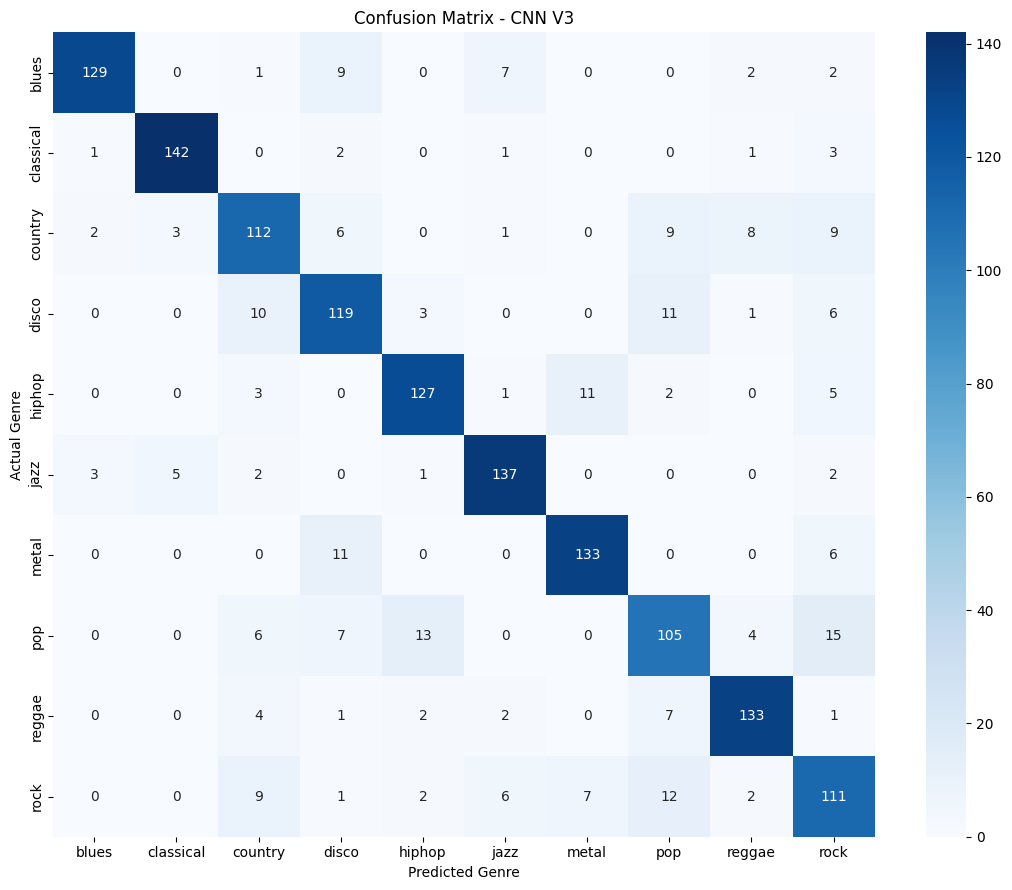

In [135]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_v3 = confusion_matrix(
    y_true_v3,
    y_pred_v3
)

plt.figure(figsize=(11, 9))

sns.heatmap(
    cm_v3,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")
plt.title("Confusion Matrix - CNN V3")

plt.tight_layout()
plt.show()

In [136]:
song_results_v3 = []

for _, row in tqdm(
    test_df.iterrows(),
    total=len(test_df)
):

    file_path = row["file_path"]
    true_genre = row["genre"]

    segments = extract_segments_with_label(
        file_path,
        true_genre
    )

    segments = segments[..., np.newaxis]

    predictions = best_model_v3.predict(
        segments,
        verbose=0
    )

    # Average probabilities from all segments
    average_prediction = np.mean(
        predictions,
        axis=0
    )

    predicted_index = np.argmax(
        average_prediction
    )

    predicted_genre = label_encoder.classes_[
        predicted_index
    ]

    song_results_v3.append({
        "file": os.path.basename(file_path),
        "actual": true_genre,
        "predicted": predicted_genre
    })

100%|██████████| 150/150 [00:54<00:00,  2.76it/s]


In [137]:
song_results_v3_df = pd.DataFrame(
    song_results_v3
)

In [138]:
from sklearn.metrics import accuracy_score

song_accuracy_v3 = accuracy_score(
    song_results_v3_df["actual"],
    song_results_v3_df["predicted"]
)

print(
    f"V3 Song-Level Accuracy: "
    f"{song_accuracy_v3 * 100:.2f}%"
)

V3 Song-Level Accuracy: 90.00%


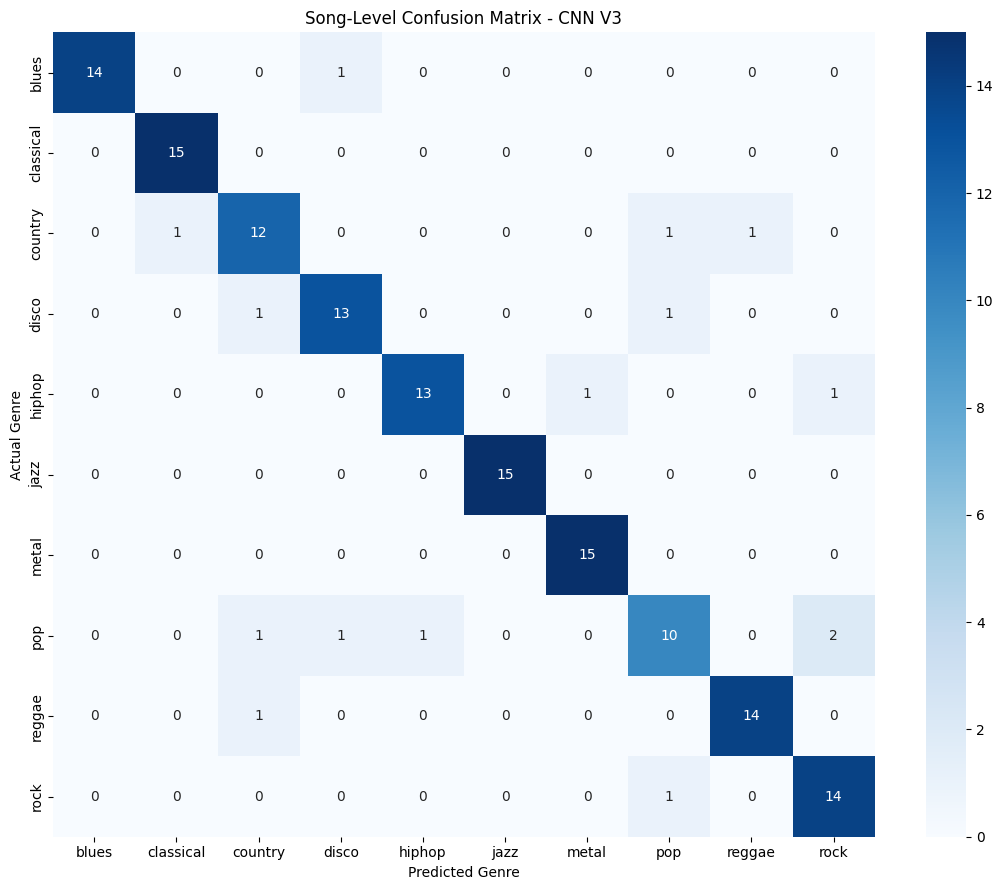

In [139]:
song_cm_v3 = confusion_matrix(
    song_results_v3_df["actual"],
    song_results_v3_df["predicted"],
    labels=label_encoder.classes_
)

plt.figure(figsize=(11, 9))

sns.heatmap(
    song_cm_v3,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")
plt.title("Song-Level Confusion Matrix - CNN V3")

plt.tight_layout()
plt.show()

In [140]:
experiment_results["CNN_V3"] = {
    "segment_accuracy": float(test_accuracy_v3),
    "song_accuracy": float(song_accuracy_v3)
}

with open(
    "/content/drive/MyDrive/MusicGenreCNN/results/experiment_results.json",
    "w"
) as f:

    json.dump(
        experiment_results,
        f,
        indent=4
    )

print("V3 results saved to Google Drive.")

V3 results saved to Google Drive.


Done V3

In [141]:
import os
import json

PROJECT_DIR = "/content/drive/MyDrive/MusicGenreCNN"
MODEL_DIR = os.path.join(PROJECT_DIR, "models")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# Save final V3 model
FINAL_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "music_genre_cnn_final_v3.keras"
)

best_model_v3.save(FINAL_MODEL_PATH)

# Save final results
final_results = {
    "model": "CNN_V3",
    "segment_accuracy": float(test_accuracy_v3),
    "song_accuracy": float(song_accuracy_v3),
    "genres": label_encoder.classes_.tolist()
}

with open(
    os.path.join(RESULTS_DIR, "final_results.json"),
    "w"
) as f:
    json.dump(
        final_results,
        f,
        indent=4
    )

print("FINAL MODEL SAVED")
print(FINAL_MODEL_PATH)
print("\nResults:")
print(json.dumps(final_results, indent=4))

FINAL MODEL SAVED
/content/drive/MyDrive/MusicGenreCNN/models/music_genre_cnn_final_v3.keras

Results:
{
    "model": "CNN_V3",
    "segment_accuracy": 0.8325550556182861,
    "song_accuracy": 0.9,
    "genres": [
        "blues",
        "classical",
        "country",
        "disco",
        "hiphop",
        "jazz",
        "metal",
        "pop",
        "reggae",
        "rock"
    ]
}


In [142]:
print(os.listdir(MODEL_DIR))
print(os.listdir(RESULTS_DIR))

['best_music_genre_cnn.keras', 'best_music_genre_cnn_v2.keras', 'CNN_V1_best.keras', 'CNN_V2_best.keras', 'CNN_V3_best.keras', 'music_genre_cnn_final_v3.keras']
['experiment_results.json', 'final_results.json']


Posting to github

In [143]:
requirements = """
numpy
pandas
matplotlib
seaborn
librosa
scikit-learn
tensorflow
tqdm
kagglehub
"""

with open(
    "/content/requirements.txt",
    "w"
) as f:
    f.write(requirements.strip())

print("requirements.txt created")

requirements.txt created


In [144]:
from google.colab import files

files.download("/content/requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [145]:
gitignore = """
# Python
__pycache__/
*.py[cod]
*.pyo

# Jupyter
.ipynb_checkpoints/

# Machine Learning
*.keras
*.h5
*.npz
*.npy
*.pkl

# Dataset
data/
datasets/

# Environment
.env
venv/
.venv/

# Google Colab
/content/

# OS
.DS_Store
Thumbs.db
"""

with open(
    "/content/.gitignore",
    "w"
) as f:
    f.write(gitignore.strip())

print(".gitignore created")

.gitignore created


In [146]:
files.download("/content/.gitignore")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [147]:
import json

final_results = {
    "project": "Music Genre Classification using CNN",
    "dataset": "GTZAN Genre Collection",

    "models": {
        "CNN_V1": {
            "segment_accuracy": 0.7338
        },

        "CNN_V2": {
            "segment_accuracy": 0.8158,
            "song_accuracy": 0.8667
        },

        "CNN_V3": {
            "segment_accuracy": float(test_accuracy_v3),
            "song_accuracy": float(song_accuracy_v3)
        }
    },

    "final_model": "CNN_V3",
    "final_song_accuracy": float(song_accuracy_v3),

    "genres": label_encoder.classes_.tolist()
}

with open(
    "/content/final_results.json",
    "w"
) as f:

    json.dump(
        final_results,
        f,
        indent=4
    )

print(json.dumps(final_results, indent=4))

{
    "project": "Music Genre Classification using CNN",
    "dataset": "GTZAN Genre Collection",
    "models": {
        "CNN_V1": {
            "segment_accuracy": 0.7338
        },
        "CNN_V2": {
            "segment_accuracy": 0.8158,
            "song_accuracy": 0.8667
        },
        "CNN_V3": {
            "segment_accuracy": 0.8325550556182861,
            "song_accuracy": 0.9
        }
    },
    "final_model": "CNN_V3",
    "final_song_accuracy": 0.9,
    "genres": [
        "blues",
        "classical",
        "country",
        "disco",
        "hiphop",
        "jazz",
        "metal",
        "pop",
        "reggae",
        "rock"
    ]
}


In [148]:
files.download("/content/final_results.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>